* You can add as many cells as you need to answer the questions.
* You can also answer any word or math based questions in a markup cell.
* Plots should have labels on the axes, legends if appropriate etc.

# Assignment 1 :  MC Simulations of Estimators of Location and Spread

In [1]:
import numpy as np
import scipy.stats

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.figsize'] = [6, 4]
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

For full marks, write the code below as a function or suite of functions that accepts another function (e.g. one that calculates $s^2$ or $s$) as an argument.

## Q1

For the first exercise you will use ``numpy`` and/or ``scipy`` and/or your own functions to test the formula for the estimated sample variance $s^2$.  

1. Do a _Monte Carlo_ (MC) simulation by drawing $M$ samples of $N$ data points, where $M$ is some very large number (like 10000). Each sample of $N$ data points is drawn from a Gaussian distribution with mean $\mu = 0$ and $\sigma^2 = 1$.

2. For each sample, <mark>calculate the _sample_ variance $s^2$</mark> using the standard formula. 
<mark>You can use builtin functions to do this on numpy arrays, or write your own. If the former, read the function docs carefully.</mark>

3. <mark>Save the values of $s^2$ in an array of length $M$</mark>. We are using a MC method to estimate what is called the _sampling distribution_, or, more specifically, the _sampling distribution of the sample variance_.

4. Then <mark>calculate the mean and variance of $s^2$ over all the $M$ MC samples</mark>, i.e the mean and variance of the sampling distribution.

5. Plot the mean $s^2$ (over all $M$ MC samples), $\overline{s^2}$, along with errorbars that show the <mark>_standard error_ in $\overline{s^2}$ (not the standard deviation of $s^2$)</mark>, as a function of $N$ from $N = 2$ to $N = 30$. Plot a line showing the <mark>expected value of $s^2$ for the population</mark>.

6. What is the $\chi^2$ of the simulated data points plotted in 5) compared to the model line? <mark>Is it an acceptable fit?</mark>

7. Based on this Monte Carlo experiment, is the sample variance estimator ($s^2$) unbiased?


### Step 1

In [2]:
def compute_variance_of_sample(data):
    variance = np.var(data, ddof=1)         # ddof = 1 because we are estimating the mean from the data (N-1 factor)
    
    return variance

def estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(function_that_computes_metric, M, N, rng):
    estimates_for_each_sample = np.empty(shape=M)

    for i in range(0,M):
        sample = rng.normal(loc=0,scale=1,size=N)            # N(mu=0,std=1)
        estimates_for_each_sample[i] = function_that_computes_metric(sample)

    return estimates_for_each_sample

def compute_standard_error_of_sample(sample_variance, N):
    standard_error = np.sqrt(sample_variance / N)

    return standard_error

def compute_chi2_of_data(data, model, uncertainty):
    chi2 = np.sum( ( (data - model)/(uncertainty) )**2 )

    return chi2  

def compute_reduced_chi2(chi2, dof):
    rdchi2 = chi2 / dof
    
    return rdchi2   


In [3]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

rng = np.random.default_rng()

### Step 2 and 3 

In [4]:
estimates_of_variance = []          # holds the variances estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    variance_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_variance_of_sample, M, N, rng)      # shape (10000,), contains 10000 variance values for a given N 
    estimates_of_variance.append(variance_estimates)

print(estimates_of_variance)        # array of 10000 s2 values for each N

[array([3.24038556, 0.01758179, 0.31951421, ..., 0.27253121, 0.75320409,
       3.82306296], shape=(10000,)), array([0.48656763, 0.30269531, 1.837908  , ..., 0.36733891, 0.12701159,
       0.09732341], shape=(10000,)), array([0.28819593, 3.38138783, 1.40706511, ..., 1.36081388, 0.48929397,
       0.20761098], shape=(10000,)), array([1.33846158, 0.34309116, 1.28953769, ..., 1.52290331, 0.8206187 ,
       0.89822043], shape=(10000,)), array([1.17420137, 0.79011988, 0.49515557, ..., 0.88147143, 0.32353815,
       0.48480715], shape=(10000,)), array([1.2877032 , 0.72890767, 0.60852493, ..., 0.27075097, 1.78733642,
       0.51563271], shape=(10000,)), array([1.35709579, 2.04143542, 1.41709433, ..., 0.40104458, 0.37517738,
       0.6743833 ], shape=(10000,)), array([2.44183379, 0.85971401, 1.14606491, ..., 0.29913544, 0.80820063,
       1.65185145], shape=(10000,)), array([1.01373595, 1.14086303, 0.69416223, ..., 0.5889689 , 1.59619367,
       1.9114221 ], shape=(10000,)), array([0.83722196,

### Step 4

In [5]:
means_of_estimates_of_variance = []      # holds the mean of all 10000 variances computed for a given N                  # shape (29, 1)
for estimates in estimates_of_variance: 
    mean = np.mean(estimates)           # computes the mean of all 10000 variances          # shape (1,)
    means_of_estimates_of_variance.append(mean)   

variances_of_estimates_of_variance = []  # holds the variance of all the 10000 variances computed for a given N          # shape (29, 1)
for estimates in estimates_of_variance:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_variance.append(var)

print(means_of_estimates_of_variance)            # array of the avg of all 10000 s2 values for a given N     
print()
print(variances_of_estimates_of_variance)        # array of the s2 of all 10000 s2 values for a given N 

[np.float64(0.9729184522825773), np.float64(0.9982252228321701), np.float64(0.9978994748093537), np.float64(1.0128316042331262), np.float64(0.9899057100139402), np.float64(0.9973333249612671), np.float64(1.006039311124288), np.float64(1.004454034831955), np.float64(1.0049579821827581), np.float64(0.9969998362845145), np.float64(1.0004425786276023), np.float64(0.997828152918856), np.float64(0.9973058869544753), np.float64(1.0000314944513982), np.float64(0.9933152569072552), np.float64(1.0006203329680756), np.float64(1.000764628190607), np.float64(1.0004641756120227), np.float64(1.0001209421498185), np.float64(0.9969555771988733), np.float64(1.0065583272339824), np.float64(0.9987588341391936), np.float64(1.000957638982097), np.float64(0.9953386826348875), np.float64(0.9903510840749983), np.float64(0.998933733710411), np.float64(0.9968936892739634), np.float64(0.9975262023133812), np.float64(1.001352470145956)]

[np.float64(1.9229037005856706), np.float64(1.03042324852169), np.float64(0.6

### Step 5

standard error in the mean is:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}} = \sqrt{ \frac{\sigma^2}{N} }
$$

but the population variance $\sigma^2$ is unknown, so we estimate the standard error by substituting the sample variance $s^2$

\begin{equation*}
    \sigma_{\bar{x}} = \sqrt{ \frac{s^2}{N} }
\end{equation*}

so that the standard error of the mean variance with M sample size is 

\begin{equation*}
    \sigma_{\bar{s^2}} = \sqrt{ \frac{\rm var(s^2)}{M} }
\end{equation*}

In [6]:
standard_errors_of_means_of_estimates_of_variance = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_variance:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the variances -> we computed the avg of all 10000 s2 values so N=10000
    standard_errors_of_means_of_estimates_of_variance.append(stderr)

print(standard_errors_of_means_of_estimates_of_variance)            # array of stderr for each mean of variance     # shape (29 , 1)

[np.float64(0.013866880328991343), np.float64(0.010150976546725393), np.float64(0.00807198427668217), np.float64(0.007217907060604258), np.float64(0.00627947806146195), np.float64(0.005741701147892468), np.float64(0.005426605125514509), np.float64(0.004984293962563449), np.float64(0.004771885181018595), np.float64(0.004455783045818397), np.float64(0.004186343520787459), np.float64(0.004094507890914158), np.float64(0.003950006108938812), np.float64(0.003751190569200502), np.float64(0.0036502495098497617), np.float64(0.0034699555001077636), np.float64(0.003414164264561751), np.float64(0.0033114251660279702), np.float64(0.003278353191877555), np.float64(0.0031326157756902677), np.float64(0.003092361744262233), np.float64(0.0029696719772525767), np.float64(0.0029727013805351415), np.float64(0.0028595035953312823), np.float64(0.002819394737915838), np.float64(0.002771356967657543), np.float64(0.002716565096000629), np.float64(0.0027037460616142046), np.float64(0.002607682045635194)]


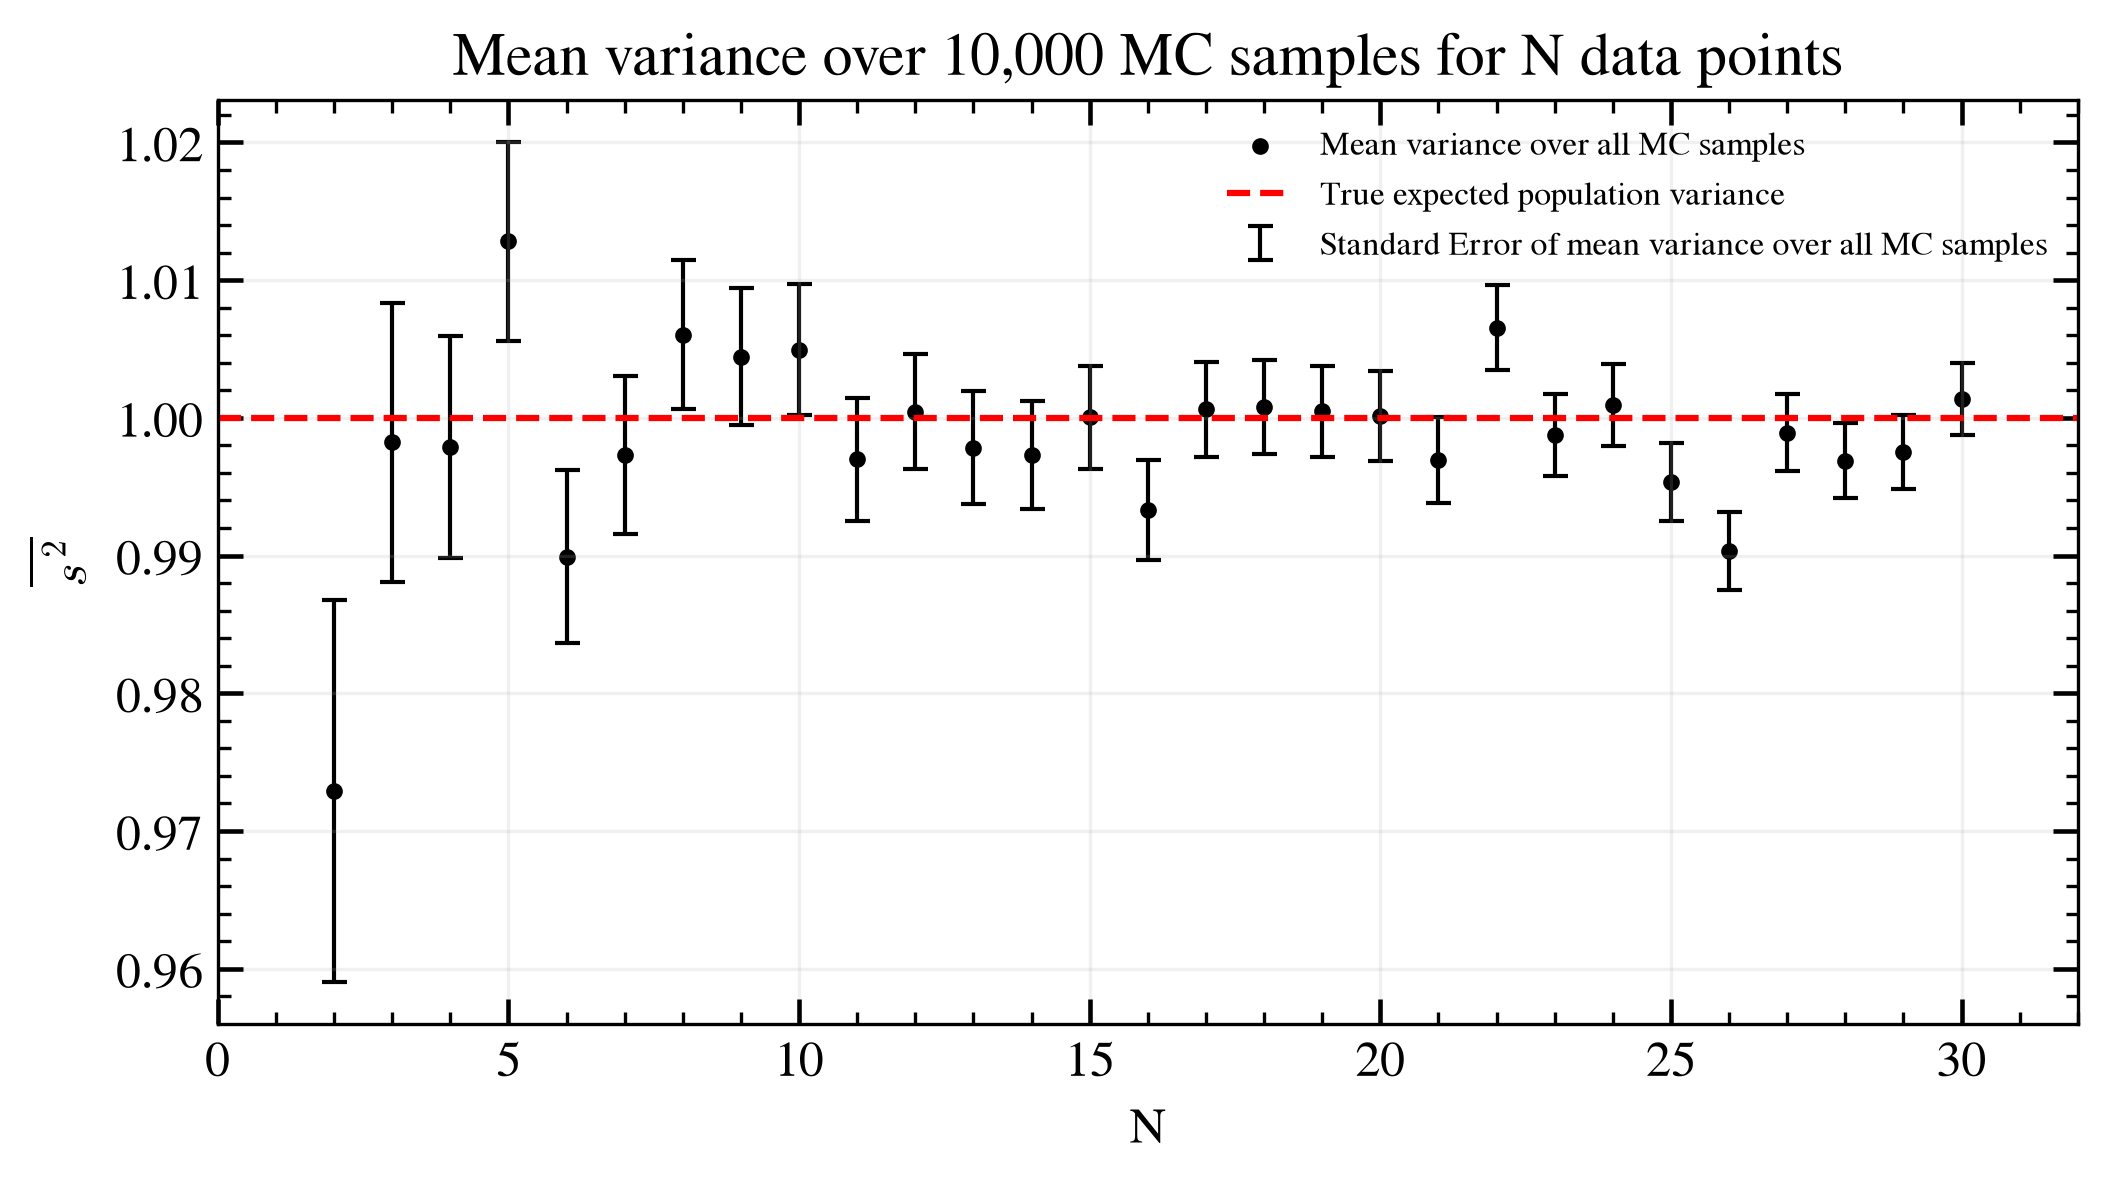

In [7]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s^2}$')
ax.set_title("Mean variance over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_variance, marker='.', label="Mean variance over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_variance, 
    yerr=standard_errors_of_means_of_estimates_of_variance,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean variance over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True expected population variance')    # true E[s2] for normal ~N(0,1) is 1

ax.legend(frameon=False, fontsize=8, loc='best')

### Step 6

The $\chi^2$ relative to y = 1 is given by 

\begin{equation*}

\chi^2 = \sum_i^N \frac{(y_i - f_i)^2}{\sigma_i^2}

\end{equation*}
where $y_i$ is measured and $f_i$ is the model, $\sigma_i$ is the uncertainty in $y_i$. 

In our case, $y_i = \overline{s^2}$ , $f_i = 1$, and $\sigma_i=$ standard error of $\overline{s^2}$

\begin{equation*}

\chi^2 = \sum_2^{30} \bigg( \frac{\overline{s^2} - 1}{SE[\overline{s^2}]} \bigg)^2

\end{equation*}

In [8]:
data = np.asarray(means_of_estimates_of_variance)
model = np.ones_like(data)
unc = np.asarray(standard_errors_of_means_of_estimates_of_variance)

chi2_of_means_of_estimates_of_variance = compute_chi2_of_data(data,model,unc)           #gives a singular chi2 value for the fit to the data

dof = len(N_array) - 0                   # dof = N - numbers of parameters = 29 since we have 29 data points and no parameters (model is a constant)

print(f"chi2: {chi2_of_means_of_estimates_of_variance}")
print(f"reduced chi2: {compute_reduced_chi2(chi2_of_means_of_estimates_of_variance, dof=dof)}")        

pval = scipy.stats.chi2.sf(chi2_of_means_of_estimates_of_variance, dof)
print(f"p value: {pval}") 


chi2: 40.30927051630757
reduced chi2: 1.3899748453899163
p value: 0.07900593833564608


In [9]:
# Goodness of fit
if pval < 0.05:         # reject H0 that data and model are the same
    print(f'This is not a good fit. With a p = {pval:2f} < 0.05, we must reject the prediction that the data and the model are equal.')

if pval >= 0.05:         # reject H0 that data and model are the same
    print(
        f'This is a good fit. With a p = {pval:2f} >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal.' ,
        f'\nThus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.'
    )

This is a good fit. With a p = 0.079006 >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal. 
Thus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.


### Step 7

Given that the MC mean of the sample variance is consistent with the true population mean of $1$ across $N = 2,3,...,30$ sample sizes and that the chi-squared did not yield any significant disagreement with this prediction, I claim that based on this MC experiment that the estimator is <b>unbiased</b> since its measured metric averaged over a large sample size did not deviate from the true population value. 

## Q2

In a variant of the above exercises, suppose for each sample of size $N$ drawn from a normal distribution, you calculate both the _sample_ mean $\bar{x}$ and the _sample_ variance $s^2$. Then define the statistic:
$$
Z = \frac{\bar{x}}{s/\sqrt{N}}
$$

a) For $N=5$, $M = 100,000$, plot a histogram of $Z$. Overplot a normal distribution.

b) Repeat for $N=100$.


c)  Is it the overplotted normal distribution [in parts a) and b)] a good fit? If not, why and in what way does it differ?

### Part a)

In [10]:
N = 5
M = 100000

def compute_Z(data):
    sample_mean = np.mean(data)
    sample_variance = compute_variance_of_sample(data)
    N = len(data)
    
    Z = sample_mean / (np.sqrt(sample_variance / N))

    return Z

In [11]:
Z_estimates_for_N_5 = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_Z, M=M, N=N, rng=rng)       # array of 100000 Z values for N = 5

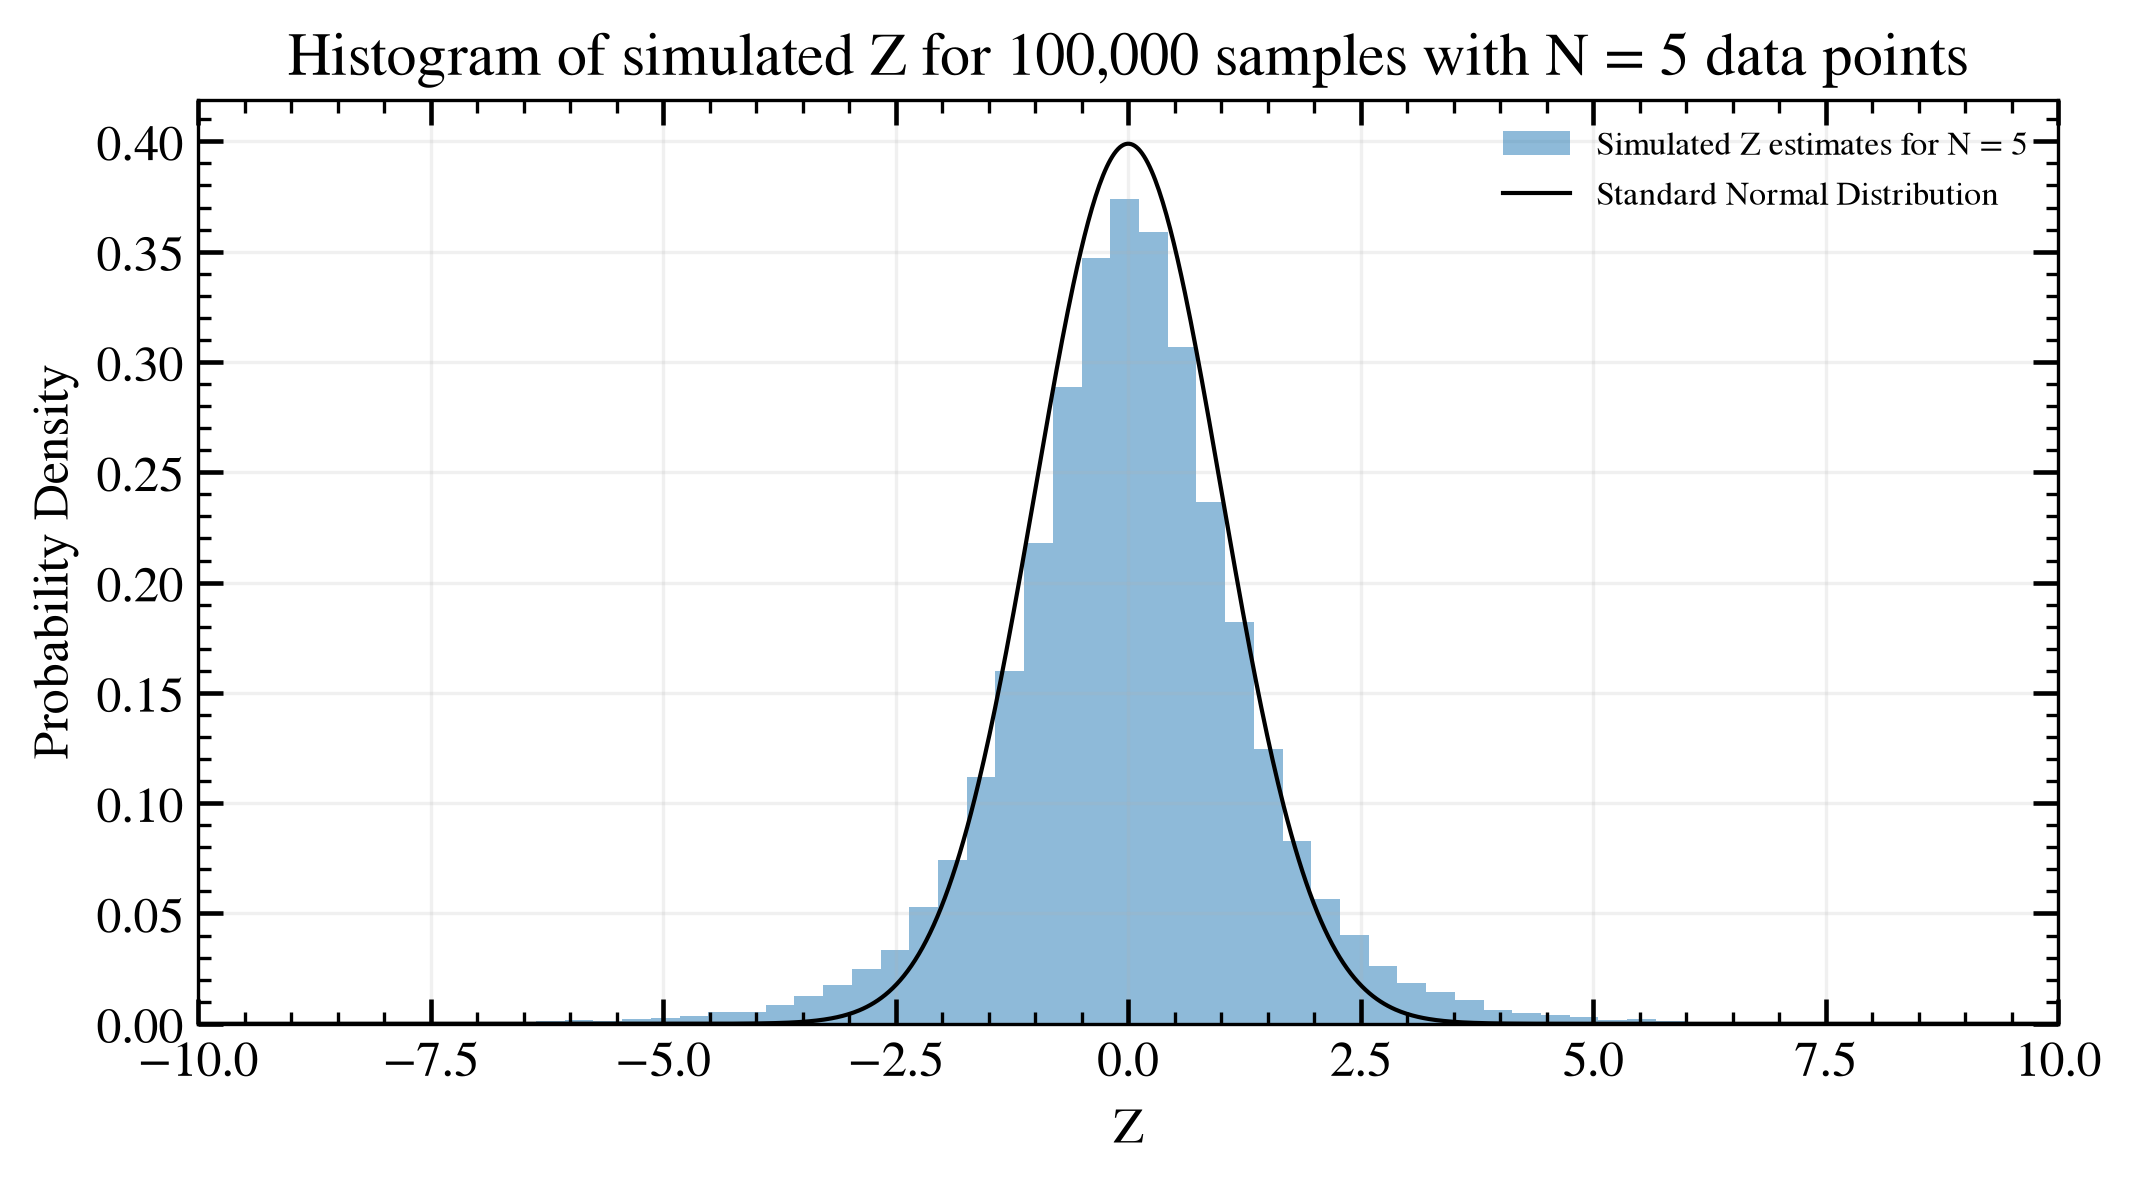

In [12]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

z_space = np.linspace(-10,10,1000)
N01 = scipy.stats.norm.pdf(z_space, loc=0, scale=1)       # Normal distr with mu = 0 and std = 1

ax.hist(Z_estimates_for_N_5, density=True, histtype='stepfilled', alpha=0.5, label='Simulated Z estimates for N = 5', bins=200)
ax.plot(z_space, N01, 'k-', lw=1, label='Standard Normal Distribution')

ax.set_xlabel('Z')
ax.set_ylabel('Probability Density')
ax.set_title("Histogram of simulated Z for 100,000 samples with N = 5 data points")
ax.set_xlim(z_space[0],z_space[-1])
# ax.set_ylim(0,1)
ax.legend(frameon=False, fontsize=8, loc='best')

### Part b)

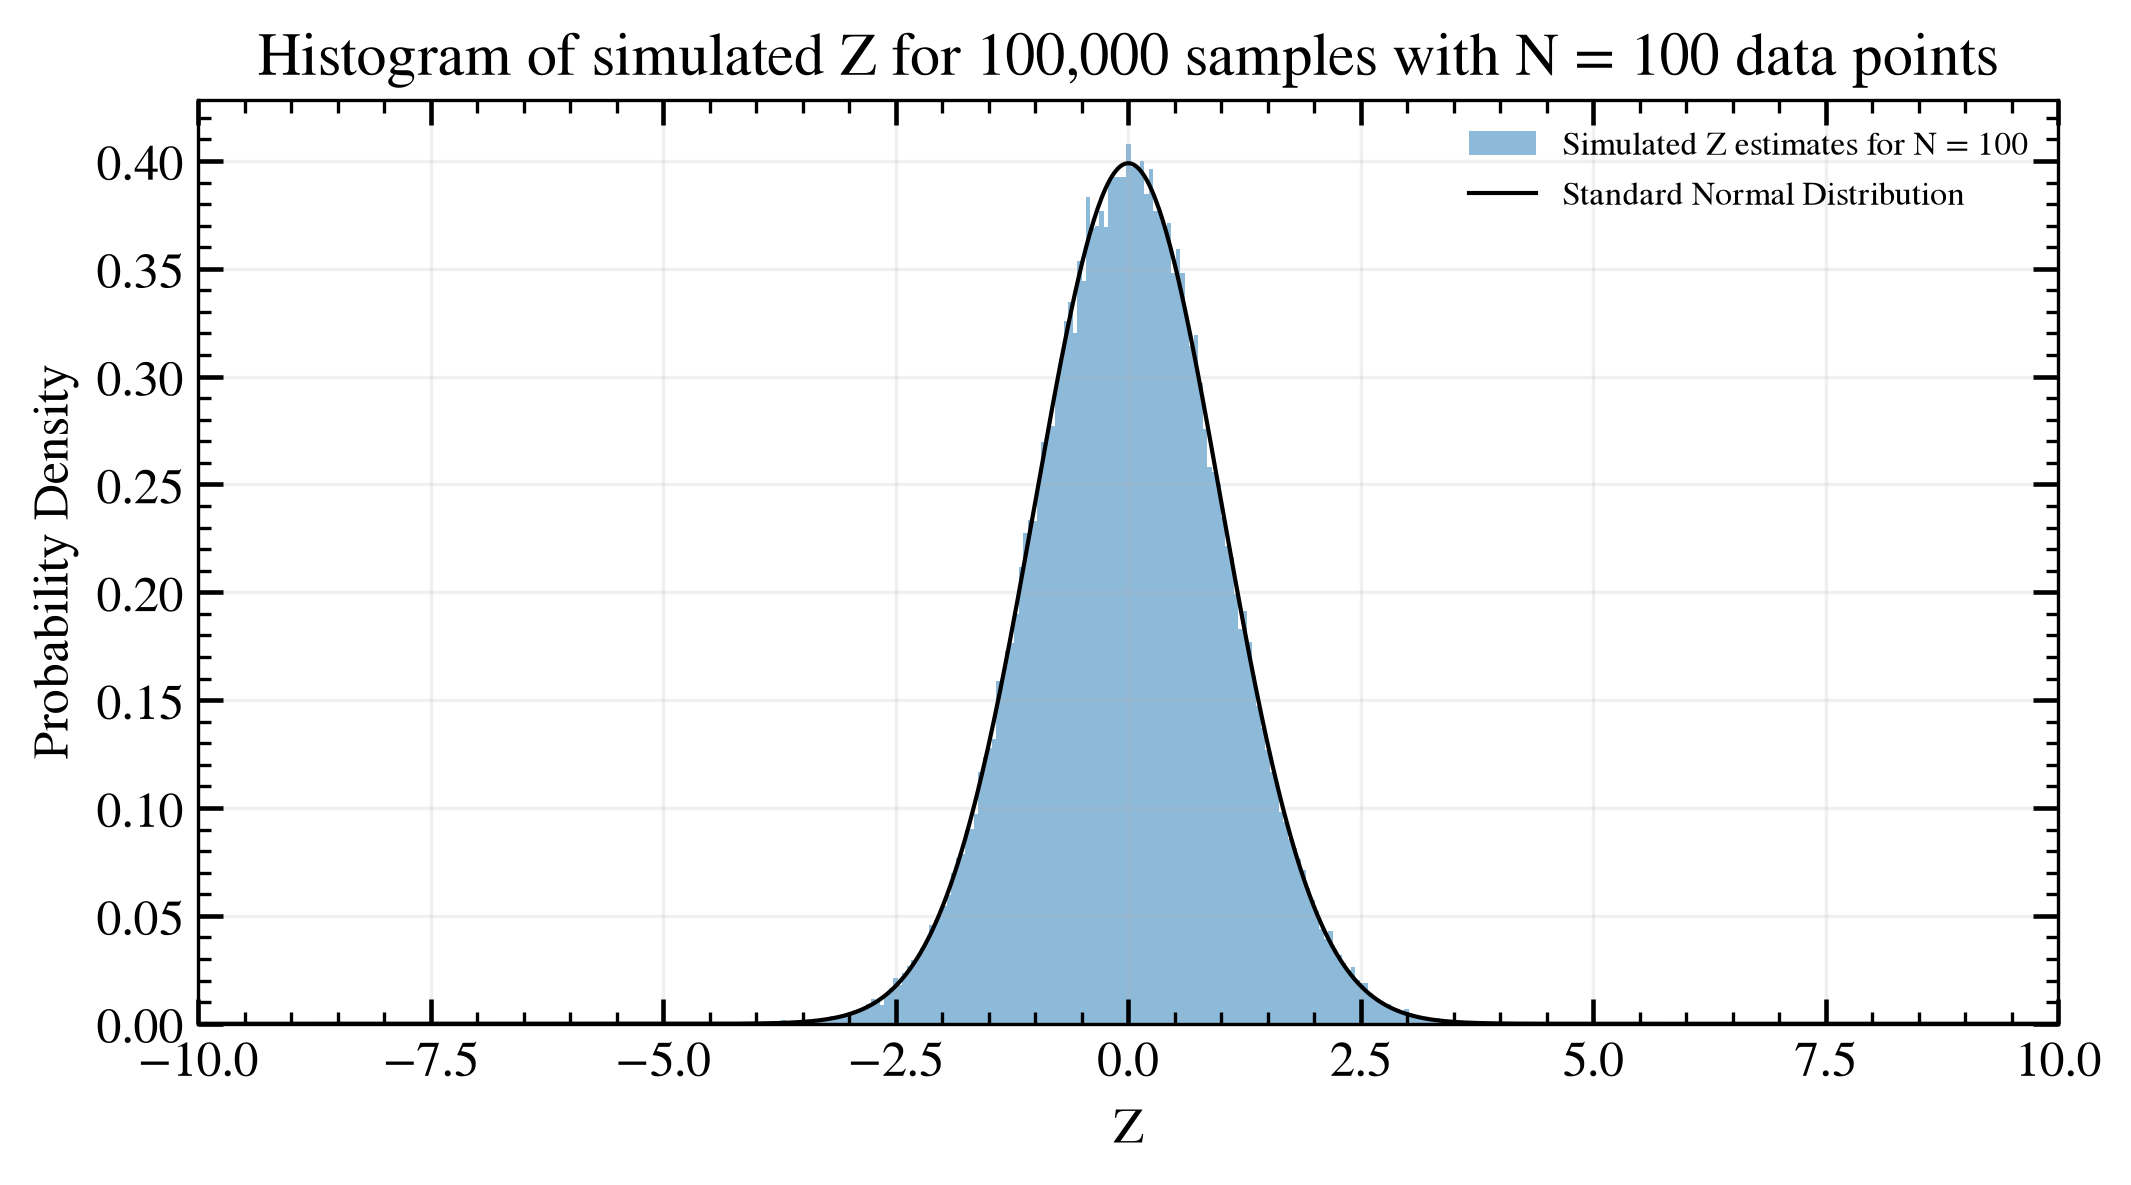

In [13]:
N = 100
M = 100000

Z_estimates_for_N_100 = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_Z, M=M, N=N, rng=rng)       # array of 100000 Z values for N = 100

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

z_space = np.linspace(-10,10,1000)
N01 = scipy.stats.norm.pdf(z_space, loc=0, scale=1)       # Normal distr with mu = 0 and std = 1

ax.hist(Z_estimates_for_N_100, density=True, histtype='stepfilled', alpha=0.5, label='Simulated Z estimates for N = 100', bins=200)
ax.plot(z_space, N01, 'k-', lw=1, label='Standard Normal Distribution')

ax.set_xlabel('Z')
ax.set_ylabel('Probability Density')
ax.set_title("Histogram of simulated Z for 100,000 samples with N = 100 data points")
ax.set_xlim(z_space[0],z_space[-1])
# ax.set_ylim(0,1)
ax.legend(frameon=False, fontsize=8, loc='best')

### Part c)

I would say that in part a), the overplotted normal distribution is <b>not a good fit</b>. This is because it overestimates the probability density near the peak at zero and underestimates the probability density in the tails away from $z = 0$.

In part b) however, the overplotted normal distribution is <b>indeed a good fit</b> as it closely follows the underlying probability density without over or underestimating near the peak and in the tails. 

## Q3

Now repeat Q1, but in steps 2-6 replace the sample variance $s^2$ with its square root, the sample standard deviation $s$.

Are the results the same as for $s^2$? Explain.

In [14]:
def compute_std_of_sample(data):
    std = np.std(data, ddof=1)
    
    return std 

### Step 1 (reset M and N)

In [15]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

### Step 2 and 3

In [16]:
estimates_of_std = []          # holds the std estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    std_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_std_of_sample, M, N, rng)      # shape (10000,), contains 10000 std values for a given N 
    estimates_of_std.append(std_estimates)

print(estimates_of_std)        # array of 10000 s values for each N

[array([0.36054233, 1.2693314 , 0.80241172, ..., 0.62050345, 0.40790566,
       0.39163377], shape=(10000,)), array([0.20298803, 0.3946274 , 0.15552169, ..., 0.74364742, 1.49727148,
       1.99028465], shape=(10000,)), array([0.433356  , 1.04871536, 1.73282591, ..., 1.13737189, 1.13810769,
       0.61890403], shape=(10000,)), array([0.72327016, 0.85738737, 1.29018673, ..., 0.59848402, 0.96928477,
       0.37926101], shape=(10000,)), array([1.01076199, 1.51527605, 1.00970499, ..., 0.82179   , 1.68656114,
       1.18909705], shape=(10000,)), array([0.88436147, 0.47419794, 0.6658181 , ..., 0.38435834, 1.38684917,
       1.0037465 ], shape=(10000,)), array([1.05034654, 0.72934521, 0.58980144, ..., 1.02740796, 1.09495147,
       1.07522282], shape=(10000,)), array([0.92476742, 0.75799338, 1.31814772, ..., 1.23956776, 0.6132084 ,
       0.89946901], shape=(10000,)), array([0.93705785, 0.78855549, 1.70397039, ..., 1.60080053, 1.00275371,
       0.89242845], shape=(10000,)), array([1.01807434,

### Step 4

In [17]:
means_of_estimates_of_std = []      # holds the mean of all 10000 std computed for a given N                  # shape (29, 1)
for estimates in estimates_of_std: 
    mean = np.mean(estimates)           # computes the mean of all 10000 std          # shape (1,)
    means_of_estimates_of_std.append(mean)   

variances_of_estimates_of_std = []  # holds the variance of all the 10000 std computed for a given N          # shape (29, 1)
for estimates in estimates_of_std:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_std.append(var)

print(means_of_estimates_of_std)            # array of the avg of all 10000 s values for a given N     
print()
print(variances_of_estimates_of_std)        # array of the s2 of all 10000 s values for a given N 

[np.float64(0.7967934967472847), np.float64(0.8845527962248263), np.float64(0.9176730641830202), np.float64(0.9312064221548422), np.float64(0.9516735891946668), np.float64(0.9628870884258391), np.float64(0.9658290669981027), np.float64(0.9674099689100354), np.float64(0.9728723027856792), np.float64(0.9762952162234307), np.float64(0.9757524529952701), np.float64(0.9788666743880508), np.float64(0.9783079923631153), np.float64(0.9812823875196275), np.float64(0.980618282703769), np.float64(0.9864610215941814), np.float64(0.9877850607908963), np.float64(0.9865380449139564), np.float64(0.9864956914263494), np.float64(0.9857104934815845), np.float64(0.9870660522099828), np.float64(0.9894865715851192), np.float64(0.9906040574766446), np.float64(0.9912256552432375), np.float64(0.9907188137566827), np.float64(0.9910137807721352), np.float64(0.9909488168195887), np.float64(0.9912191212587365), np.float64(0.9910340973307157)]

[np.float64(0.3610393400705595), np.float64(0.21559000093728306), np.fl

### Step 5

In [18]:
standard_errors_of_means_of_estimates_of_std = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_std:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the std -> we computed the avg of all 10000 s values so N=10000
    standard_errors_of_means_of_estimates_of_std.append(stderr)

print(standard_errors_of_means_of_estimates_of_std)            # array of stderr for each mean of std     # shape (29 , 1)

[np.float64(0.00600865492494418), np.float64(0.004643167032718973), np.float64(0.0038668748823356388), np.float64(0.0034261401667845734), np.float64(0.0030751031394376867), np.float64(0.00281914051140587), np.float64(0.0026041565921316964), np.float64(0.0024516631005507407), np.float64(0.002325235735754605), np.float64(0.0021915433863488936), np.float64(0.002088039587900843), np.float64(0.002029168348044871), np.float64(0.0019484137927598885), np.float64(0.0018507180035073783), np.float64(0.0018300688337997888), np.float64(0.0017405943795853259), np.float64(0.0017018811549699023), np.float64(0.0016574390801295624), np.float64(0.0016122051264639901), np.float64(0.0015694876382569914), np.float64(0.0015294108193650588), np.float64(0.0014940139219194813), np.float64(0.0014600098704960905), np.float64(0.001445006398398664), np.float64(0.0013957144351455562), np.float64(0.0013849726662185646), np.float64(0.0013624595368337755), np.float64(0.0013405212171864996), np.float64(0.001330449239304

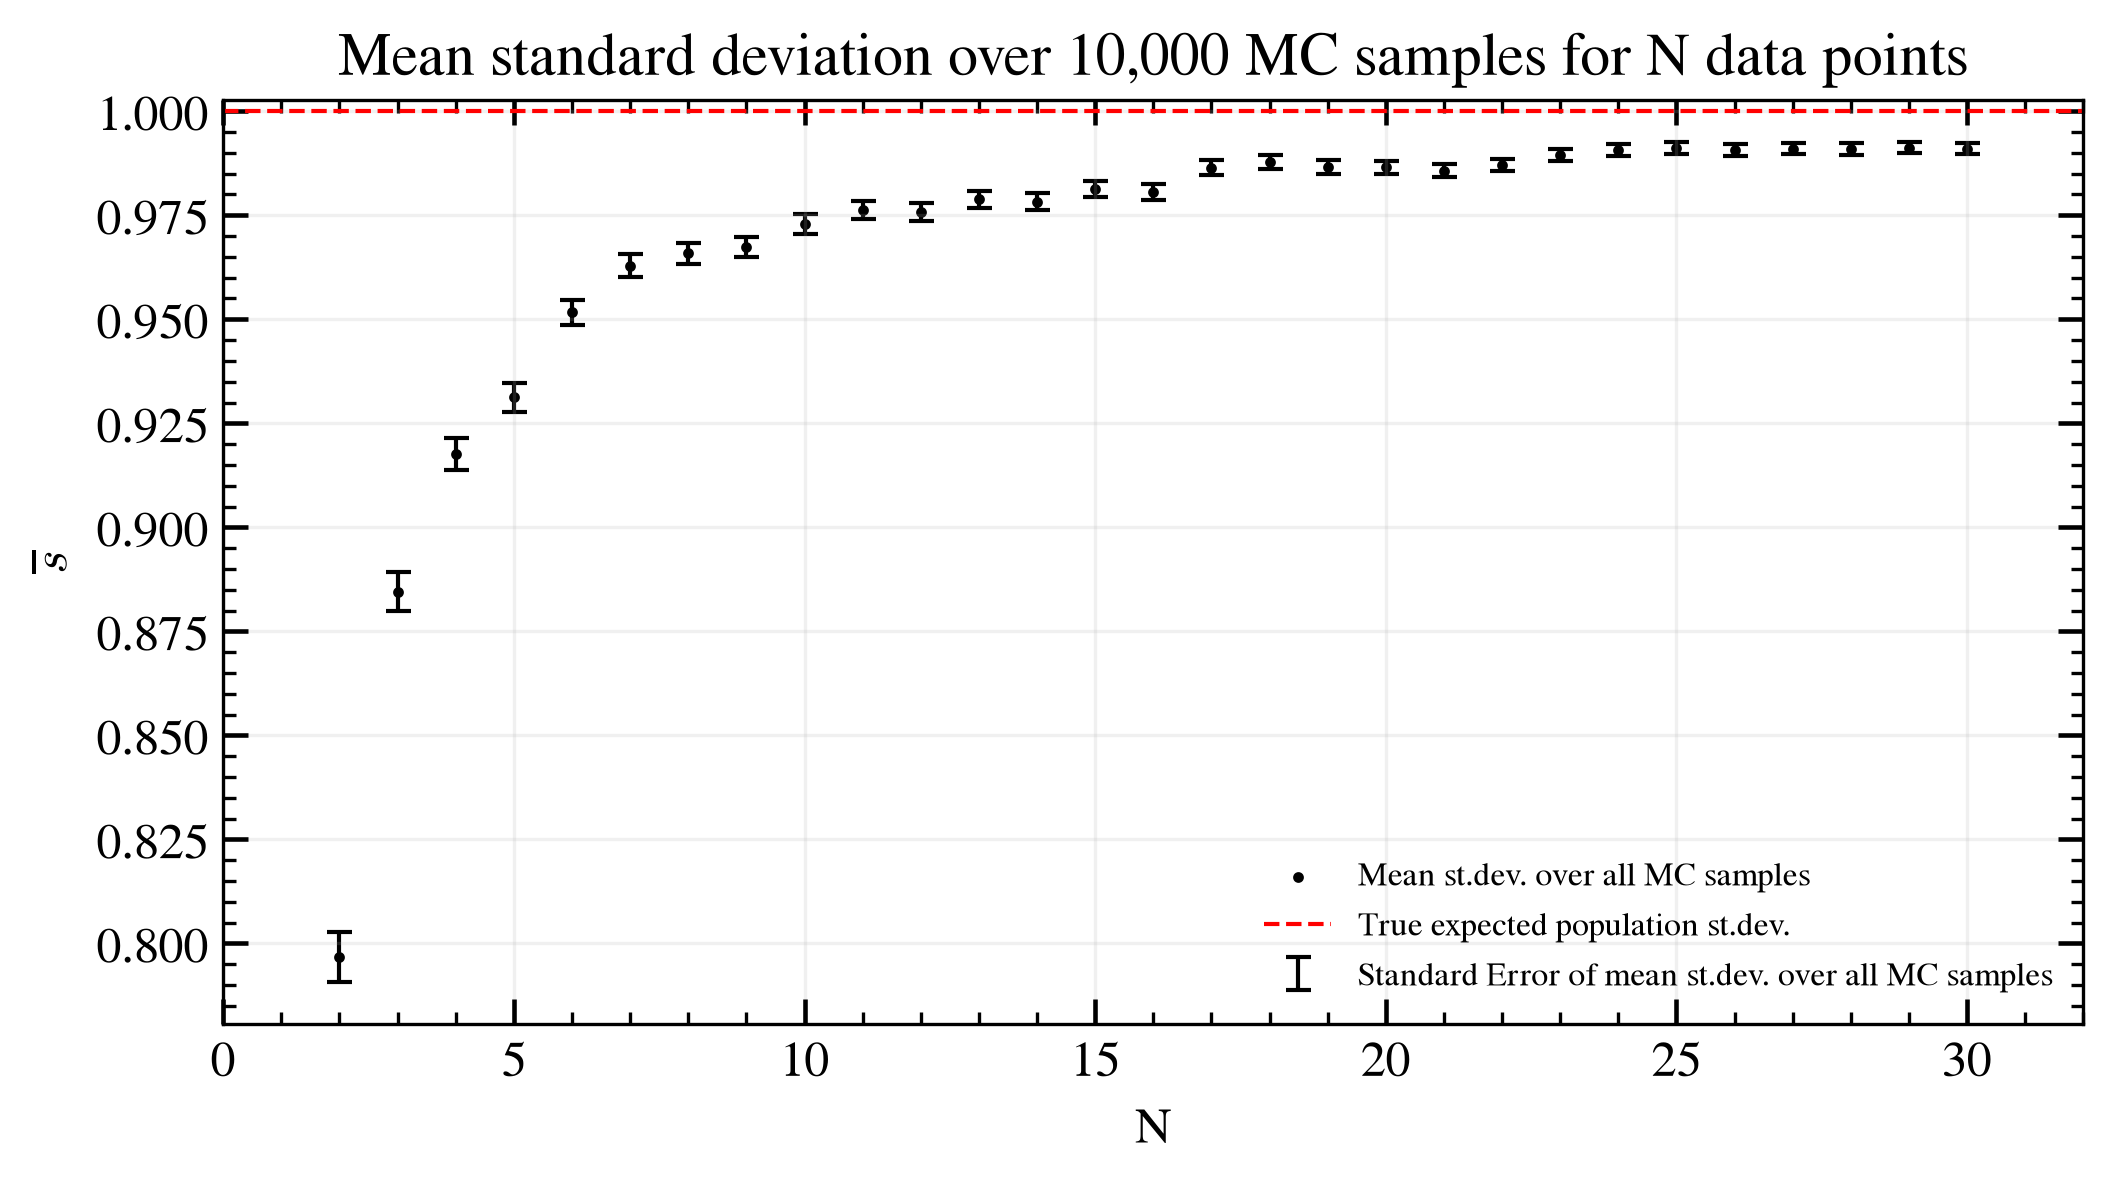

In [19]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s}$')
ax.set_title("Mean standard deviation over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_std, marker='.', s = 10, label="Mean st.dev. over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_std, 
    yerr=standard_errors_of_means_of_estimates_of_std,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean st.dev. over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True expected population st.dev.', lw = 1.0)    # true population stdev is 1

ax.legend(frameon=False, fontsize=8, loc='best')

### Step 6

In [20]:
data = np.asarray(means_of_estimates_of_std)
model = np.ones_like(data)
unc = np.asarray(standard_errors_of_means_of_estimates_of_std)

chi2_of_means_of_estimates_of_std = compute_chi2_of_data(data,model,unc)           #gives a singular chi2 value for the fit to the data

dof = len(N_array) - 0                   # dof = N - numbers of parameters = 29 since we have 29 data points and no parameters (model is a constant)

print(f"chi2: {chi2_of_means_of_estimates_of_std}")
print(f"reduced chi2: {compute_reduced_chi2(chi2_of_means_of_estimates_of_std, dof=dof)}")        

pval = scipy.stats.chi2.sf(chi2_of_means_of_estimates_of_std, dof)
print(f"p value: {pval:3e}") 


chi2: 4971.507052236061
reduced chi2: 171.43127766331244
p value: 0.000000e+00


In [21]:
# Goodness of fit
if pval < 0.05:         # reject H0 that data and model are the same
    print(f'This is not a good fit. With a p = {pval:2f} < 0.05, we must reject the prediction that the data and the model are equal.')

if pval >= 0.05:         # reject H0 that data and model are the same
    print(
        f'This is a good fit. With a p = {pval:2f} >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal.' ,
        f'\nThus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.'
    )

This is not a good fit. With a p = 0.000000 < 0.05, we must reject the prediction that the data and the model are equal.


### Explanation

The results for the sample standard deviation $s$ are different than for the sample variance $s^2$. The sample variance was an unbiased estimator but its square root, the sample standard deviation is biased since it underestimates the true population standard deviation on average. I presume this is because 

\begin{equation*}
    E[\sqrt{s^2}] \neq \sqrt{E[s^2]}
\end{equation*}


 From the MC simulation, we can see that the mean sample standard deviation is consistently below the true population standard deviation across all N's. Unlike for the variance, a chi-squared fit allows us to reject the prediction that the simulated data and the true value are the same, supporting evidence for the sample standard deviation as a biased estimator.  

## Q4

Repeat Q1 but calculate the sample _median_ instead of the sample variance.

Then calculate the mean and variance of the median over all the $M$ MC samples, i.e the mean and variance of the sampling distribution.

Plot the __ratio__ of the MC-estimated variance of the _median_ to the theoretical expectation for variance of the _mean_, as a function of $N$ from 5 to 500 (in steps of 20 or 25, say).

b) What is the asymptotic of this ratio for large $N$? Discuss the pros and cons of medians vs. means for the general case (i.e. the underlying distribution could be Gaussian or not).